# Learning machine learning by doing small projects
# source - Pluto Academy -Internship prep
# PROJECT 01 Exploratory Data Analysis & Insights Report
# The Problem Statement
# You are a Data Analyst hired at a company. Your manager has given you a real-world dataset and asked you
# to understand the data, find patterns and trends, visualize the key insights, and write a clear report with 5
# business or research recommendations based on your findings.

In [2]:
# Here i am choosing the netflix movies & tv shows dataset

# Step 1: Data Collecting and Data inspecting

In [3]:
# step 1 load and inspect the data
import pandas as pd
import numpy as np
# load the data from custom file
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from Codespace import file_paths

# take the dataframe
df = pd.read_csv(file_paths.NETFLIX_TITLE_PATH)

# check the data in dataframe
df.shape

(8807, 12)

In [4]:
# checking the null params columns
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
# checking for null/columns checking
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
# checking the duplicated rows are there
if df.duplicated().sum():
    # removing the duplicated rows
    print(f'We got the duplicated rows')
    df.drop_duplicates()
else:
    print(f'Dont have the duplicate records')

Dont have the duplicate records


# step2: Data cleaning

In [7]:
# # trying to check which dataframes has empty datasets
# if less number of empty rows -can remove them (if more important can able to fill with a value)
# if more means (can assign any parameter - related value)
# date should be of type date (in pandas there is to_datetime to convert to datetime)
# missing data columns director(2634), case (825), country (831), date_added(10), rating(4), duration(3) or you can check with above df.isnull().sum()

In [8]:
# removing the unwanted columns 
# which should not useful for the evaluation
df.drop(columns=["show_id", "description"], inplace=True)
# inplace = True means that it will change the original data frame

In [9]:
df.isnull().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
dtype: int64

In [10]:
# we are going to fill the columns with Unknown as for director, cast, country
df.fillna({"director": "Unknown", "cast": "Uknown", "country": "Unknown"}, inplace=True)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Uknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,Unknown,Uknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8803,TV Show,Zombie Dumb,Unknown,Uknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies"
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies"


In [11]:
# now we are going to remove the less number of records from rating, duration and date_added columns
df.dropna(subset=["rating", "duration", "date_added"], inplace=True)

In [12]:
# now again checking the null values
df.isnull().sum()
# we didn't get any empty records

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [13]:
# now we will try to format the fields
# datetime field should be datetime not string
# removing the whitespaces
df["date_added"] = df["date_added"].str.strip()

# converting to datetime
df["date_added"] = pd.to_datetime(df["date_added"])

# splitting it to year and month - for charts
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

df["year_added"].value_counts().head()
df["month_added"].value_counts().head()

month_added
7     827
12    812
9     769
4     763
10    760
Name: count, dtype: int64

In [14]:
# let's change the duration of the movies
df["duration"] = df["duration"].str.strip()

# now lets divide the number and unit
df["duration_time"] = df["duration"].str.extract(r'(\d+)').astype(float)
df["duration_unit"] = df["duration"].str.extract(r'([A-Za-z]+)')


df[["duration", "duration_time", "duration_unit"]]

,duration,duration_time,duration_unit
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons
...,...,...,...
8802,158 min,158.0,min
8803,2 Seasons,2.0,Seasons
8804,88 min,88.0,min
8805,88 min,88.0,min


In [15]:
# as listed_in is genre in real world taking the first one as currently it is a combination of genre
df["primary_genre"] = df["listed_in"].str.split(',').str[0].str.strip()

In [16]:
# checking the count of genres
df["primary_genre"].value_counts().head(10)

primary_genre
Dramas                      1599
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

In [17]:
# now we need to strip the text columns here!!, type, rating , country
df["type"] = df["type"].str.strip()
df["country"] =  df["country"].str.strip()
df["rating"] = df["rating"].str.strip()
# we will make sure that type should be unique as well as rating
df["type"].unique()
df["rating"].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str

In [18]:
df.shape

(8790, 15)

In [19]:
df.dtypes

type                        str
title                       str
director                    str
cast                        str
country                     str
date_added       datetime64[us]
release_year              int64
rating                      str
duration                    str
listed_in                   str
year_added                int32
month_added               int32
duration_time           float64
duration_unit               str
primary_genre            object
dtype: object

In [20]:
df.head(5)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,duration_time,duration_unit,primary_genre
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Uknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90.0,min,Documentaries
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021,9,2.0,Seasons,International TV Shows
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1.0,Season,Crime TV Shows
3,TV Show,Jailbirds New Orleans,Unknown,Uknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",2021,9,1.0,Season,Docuseries
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2021,9,2.0,Seasons,International TV Shows


# Step 3: EDA (Exploratory Data Analysis)

The goal of this step is to answer 5 questions

Question 1 — What is the split between Movies and TV Shows?

In [21]:
# just see the content type in Netflix
type_counts = df["type"].value_counts()
type_counts
# we can see the number of movies and TV shows in the netflix

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [22]:
# now we will get the percentage
df["type"].value_counts(normalize=True) * 100
# normalize will give the These values are calculated by dividing the count of each unique value by the sum of all counts,
# resulting in proportions that sum to 1.0 (excluding NaN values by default). 

type
Movie      69.692833
TV Show    30.307167
Name: proportion, dtype: float64

Question 2: Which countries would produce the most content?

In [23]:
top_countries = df[df["country"]!="Unknown"]["country"].value_counts().head(10)
top_countries

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [24]:
# so from the above values we can say that the country with most content is USA and India as first and second respectively.

Question 3: How has Netflix grown over the years?

In [25]:
yearly_growth = df.groupby("year_added")["title"].count()
yearly_growth

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: title, dtype: int64

In [26]:
# so we can see all the released movies/TV shows according to the year wise.
# now we can find the maximum (peak year films produce)
print("Peak Year: ", yearly_growth.idxmax())
print("Peak Count: ", yearly_growth.max())
print(f"Peak content of {yearly_growth.max()} are released in the Year {yearly_growth.idxmax()} ")

Peak Year:  2019
Peak Count:  2016
Peak content of 2016 are released in the Year 2019 


Question 4: What are the most common ratings?

In [27]:
# to find the common ratings
common_ratings = df["rating"].value_counts()
common_ratings.head(1)

rating
TV-MA    3205
Name: count, dtype: int64

In [28]:
# now we got the responose as TV-MA as the highest number rating moves in Netflix 3205

In [29]:
# If we want to find the percentage for the whole
adult_count = df[df["rating"].isin(["TV-MA", "R"])].value_counts().shape[0]
# without shape[0] it will return (rows, columns) shape[0] will return rows
total_count = df.shape[0]
print(f"Total: {total_count},\nAdult: {adult_count} &\nAdult Percentage: {round((adult_count/total_count)*100,2)}%")


Total: 8790,
Adult: 4004 &
Adult Percentage: 45.55%


Question 5:What is the most common genre?

In [30]:
# finding the most common genre
common_genre = df["primary_genre"].value_counts()
common_genre.head(5)

primary_genre
Dramas                    1599
Comedies                  1210
Action & Adventure         859
Documentaries              829
International TV Shows     773
Name: count, dtype: int64

# STEP 4: VISUALIZATION

In [31]:
# imports
import matplotlib.pyplot as plt


Chart1 :Finding Countries with most content?

In [32]:
# finding the values(top_countries)
# top_countries = df[df["country"]!="Unknown"]["country"].value_counts().head(10)

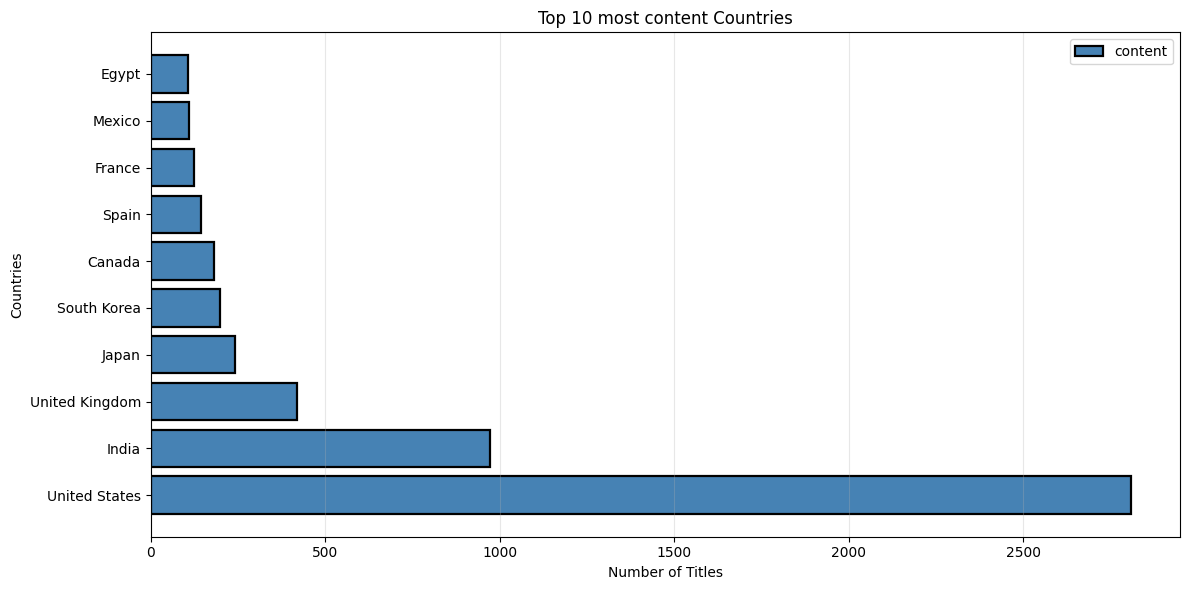

In [33]:
%matplotlib inline
# now we trying to do this by using the pyplot first
plt.style.use("default")

# as we are taking the first 10 we have to set x and y axis limit for pyplot
plt.figure(figsize=(12, 6))
plt.barh(top_countries.index, top_countries.values, color="steelblue", edgecolor="black", linewidth=1.6, label="content")
# barh is for the bar horizontally
plt.title("Top 10 most content Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Countries")
plt.tight_layout()
plt.legend()
plt.grid(True, axis='x', alpha=0.3) # alpha is to reduce the opacity of the grid
plt.show()

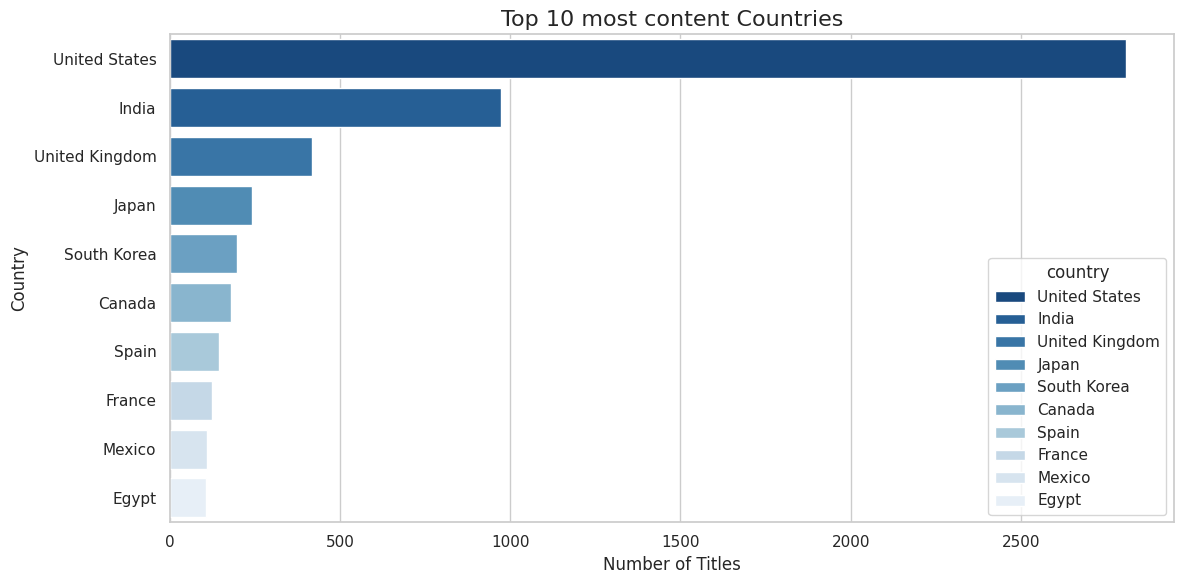

In [34]:

# as we are taking the first 10 we have to set x and y axis limit for pyplot
import seaborn as sns

# make sure the charts all
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="Blues_r", legend=True) #, palette="Blues_r", without palette all will come in different colours

plt.title("Top 10 most content Countries", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Chart 2: Line Chart

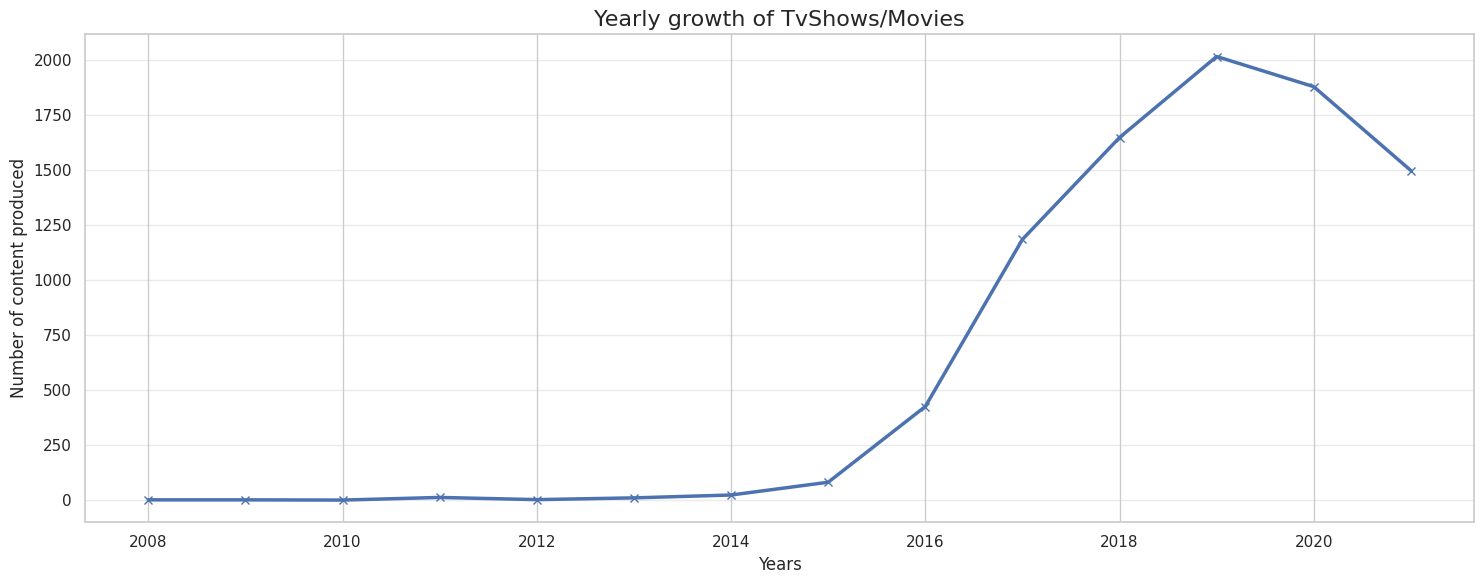

In [35]:
# we are using simple plt to draw the line chart for the years growth of films in an yearly bases count
plt.figure(figsize=(15, 6))

plt.plot(yearly_growth.index, yearly_growth.values, 'bx-', linewidth=2.5, label="content")#,marker="x", color="blue",

plt.title("Yearly growth of TvShows/Movies", fontsize=16)
plt.xlabel("Years")
plt.ylabel("Number of content produced")
plt.tight_layout()
plt.grid(True, axis="y", alpha=0.4)
plt.show()

Chart 3: Histogram

In [36]:
# finding the movies data
movies = df[df["type"]=="Movie"]

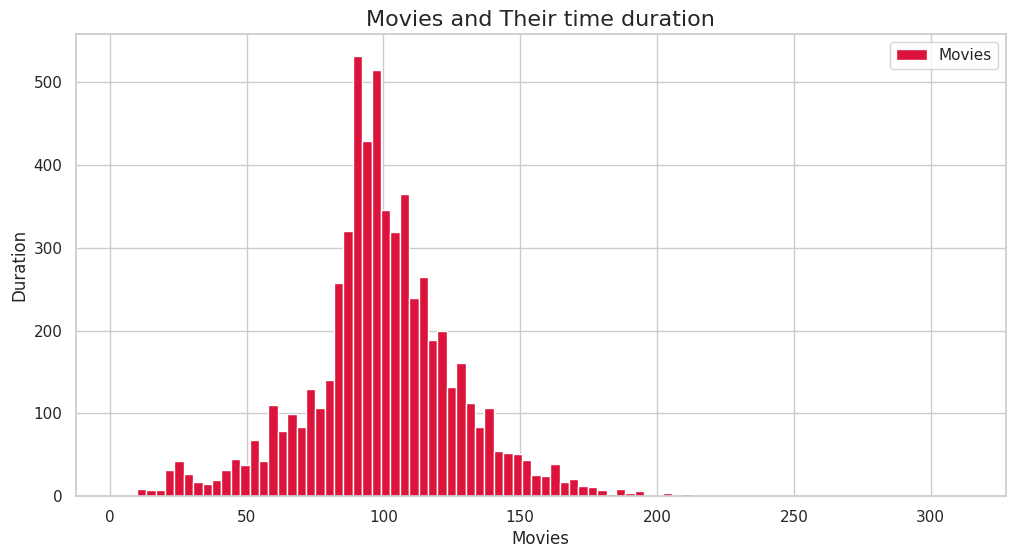

In [37]:
plt.figure(figsize=(12, 6))

plt.hist(movies["duration_time"].dropna(), color="crimson", edgecolor="white", bins=90, label="Movies")
plt.title("Movies and Their time duration", fontsize=16)
plt.xlabel("Movies")
plt.ylabel("Duration")
plt.legend()
plt.show()

/tmp/ipykernel_11897/318655620.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


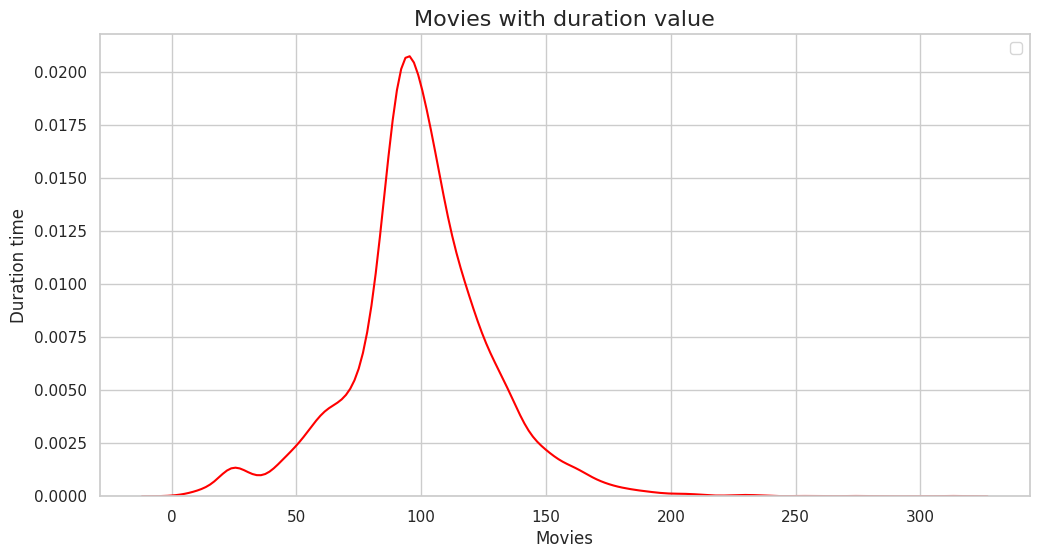

In [38]:
#using sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
# sns.histplot(movies["duration_time"].dropna(), bins=80, color="crimson", edgecolor="white", label="movies")
sns.kdeplot(movies["duration_time"], color="red")

plt.title("Movies with duration value", fontsize=16)
plt.xlabel("Movies")
plt.ylabel("Duration time")
plt.legend()
plt.show()

Chart 4: Scatter plot

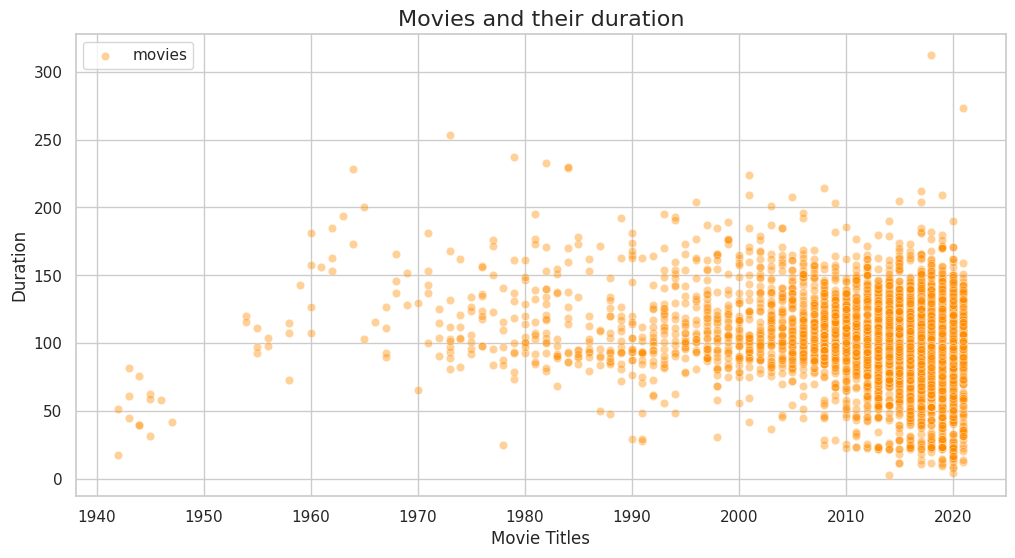

In [39]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=movies, # data
    x="release_year", # column name in the data
    y="duration_time", # column name of the data
    alpha=0.4,
    color="darkorange",
    label="movies"
)
plt.title("Movies and their duration", fontsize=16)
plt.xlabel("Movie Titles")
plt.ylabel("Duration")
plt.show()

Chart 5: Pie Chart

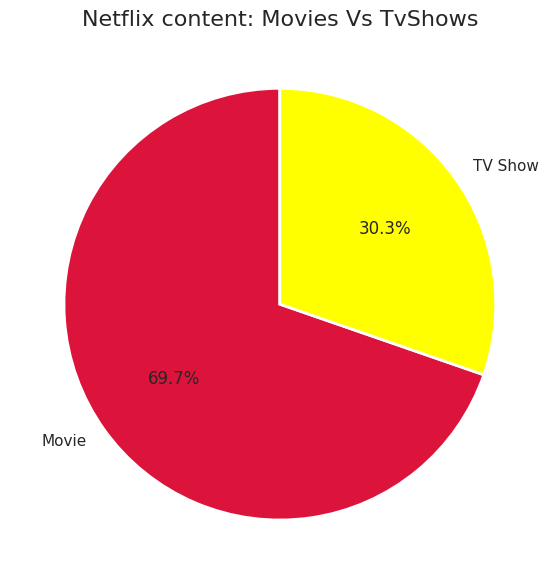

In [40]:
# using the type_counts
plt.figure(figsize=(6, 6)) # sqaure shape box

plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%", # shows the percentage, % start a number format, 1.1 show one decimal, f is a float, %% print  literal sign
    colors=["crimson", "yellow"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
plt.title("Netflix content: Movies Vs TvShows", fontsize=16)
plt.tight_layout()
plt.show()

Chart 6: HeatMap

In [41]:
# taking the data of title of movies from years_added and month_added together
pivots = df.groupby(["year_added", "month_added"])["title"].count().unstack() # unstack() will make the months as pivot

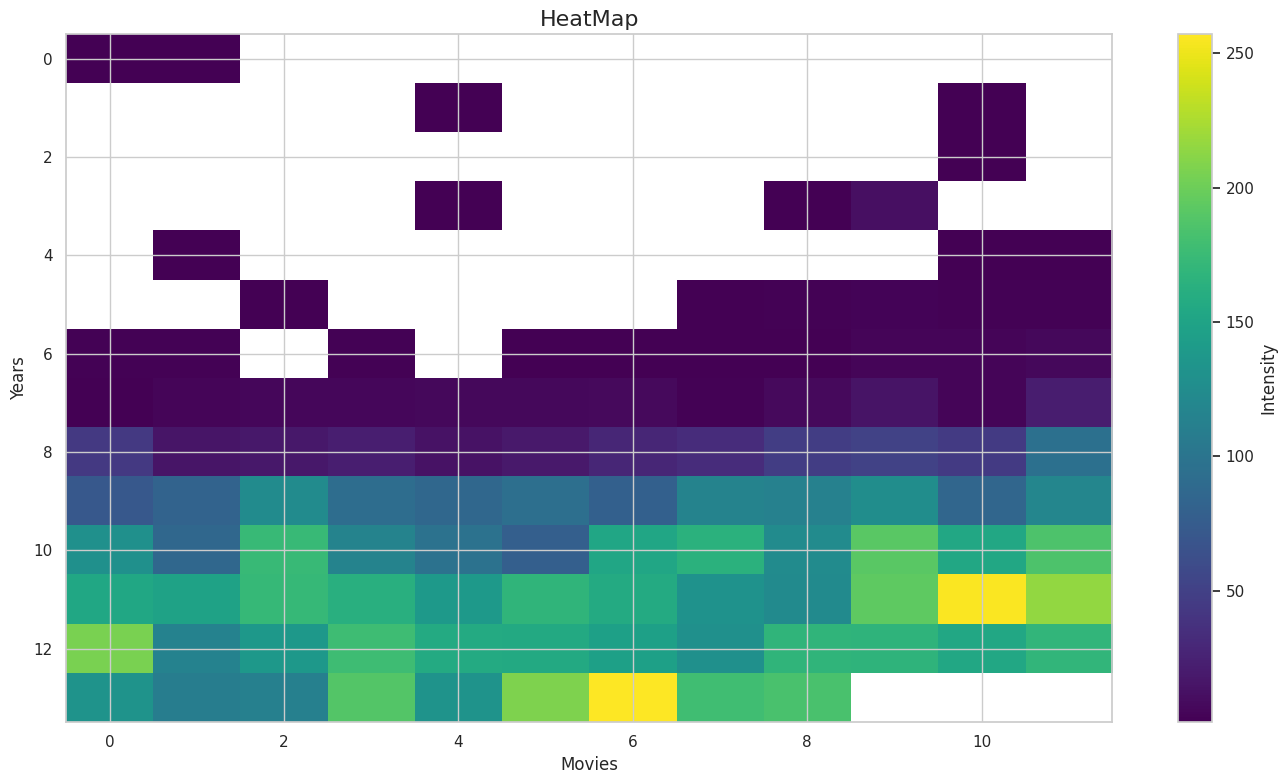

In [45]:
# using pyplot
plt.figure(figsize=(14, 8))
plt.imshow(pivots, cmap="viridis", aspect="auto", origin="upper")
plt.title("HeatMap", fontsize=16)
plt.colorbar(label="Intensity")
plt.xlabel("Movies")
plt.ylabel("Years")
plt.tight_layout()
plt.show()

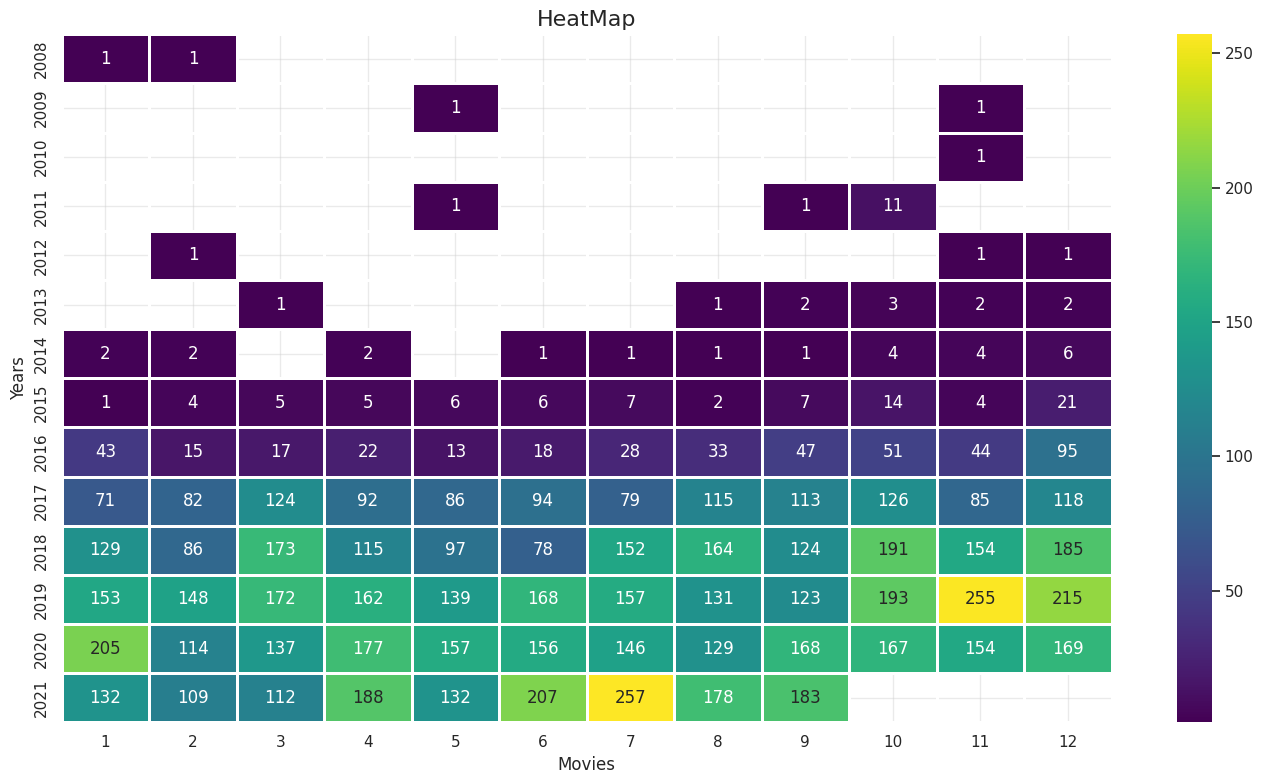

In [48]:
# using sns
plt.figure(figsize=(14, 8))
sns.heatmap(pivots, cmap="viridis", linewidth=2, annot=True, fmt='g')
plt.title("HeatMap", fontsize=16)
plt.xlabel("Movies")
plt.ylabel("Years")
plt.tight_layout()
plt.grid(True, alpha=0.4)
plt.show()

# Step 5: Insight Report

In [ ]:
# This is where everything comes together. You take every finding from Steps 3 and 4 and write it as a business recommendation 
# — not just "I found X" but "because of X, the company should do Y."


In [ ]:
'''
Insight 1 — Netflix is a Movie-First Platform, But TV Shows Drive Loyalty
Finding:  69.6% of all Netflix content is Movies, while TV Shows make up only 30.4%.

Then:-  TV Shows create binge-watching behaviour
viewers return episode after episode, season after season. Movies are watched once and forgotten. 
Despite this, Netflix has significantly underinvested in TV Show content relative to movies.

Recommendation:
    Netflix should strategically increase its TV Show library, particularly in high-engagement genres like Dramas and Thrillers.
Subscribers who binge TV Shows are less likely to cancel their subscription compared to movie-only viewers, directly reducing churn rate.

Chart: Pie Chart (Movies Vs TV Shows)
'''

'\nInsight 1 — Netflix is a Movie-First Platform, But TV Shows Drive Loyalty\nFinding:  69.6% of all Netflix content is Movies, while TV Shows make up only 30.4%.\n\nTV Shows create binge-watching behaviour\n        viewers return episode after episode, season after season. Movies are watched once and forgotten. \nDespite this, Netflix has significantly underinvested in TV Show content relative to movies.\n\nRecommendation:\n    Netflix should strategically increase its TV Show library, particularly in high-engagement genres like Dramas and Thrillers.\nSubscribers who binge TV Shows are less likely to cancel their subscription compared to movie-only viewers, directly reducing churn rate.\n\nChart: Bar Chart (Top 10 countries)\n'

In [ ]:
'''
Insight 2 - The US Dominates, But India is the Most Valuable Growth Market
Finding:  The United States produces 2,818 titles -  nearly 3x more than India (972), which sits at a distant second.
All other countries produce less than 500 titles.

Then:- India's 972 titles is impressive given that Netflix only expanded heavily into India after 2016. With 1.4 billion people and rapidly growing internet penetration, 
India represents the single largest untapped subscriber base on the planet.

Recommendation:
    Netflix should double its investment in Indian original content - specifically regional language productions beyond Hindi (Telugu, Tamil, Malayalam) to capture
the next 100 million subscribers. The data shows India already pushes far above its weight relative to other non-US markets

Chart: Bar chart (Top 10 countries)
'''

"\nInsight 2 - The US Dominates, But India is the Most Valuable Growth Market\nFinding:  The United States produces 2,818 titles -  nearly 3x more than India (972), which sits at a distant second.\nAll other countries produce less than 500 titles.\n\nIndia's 972 titles is impressive given that Netflix only expanded heavily into India after 2016. With 1.4 billion people and rapidly growing internet penetration, \nIndia represents the single largest untapped subscriber base on the planet.\n\nRecommendation:\n    Netflix should double its investment in Indian original content - specifically regional language productions beyond Hindi (Telugu, Tamil, Malayalam) to capture\nthe next 100 million subscribers. The data shows India already pushes far above its weight relative to other non-US markets\n\nChart: Bar chart (Top 10 countries)\n"

In [3]:
''' 
Insight 3 — COVID-19 Exposed a Critical Dependency on Physical Production
Finding: Netflix grew from 429 titles added in 2016 to a peak of 2,016 in 2019 — a 370% increase in just 3 years. 
Then in 2020 it dropped sharply to 1,436, and fell further to 545 in 2021.

Then:- This cliff-edge drop directly coincides with global COVID-19 production shutdowns. 
Netflix's entire content pipeline was dependent on physical filming — when studios closed, the pipeline dried up completely.

Recommendation:
    Netflix should invest in animation studios, documentary production, and licensed archive content as COVID-proof content pipelines. 
These formats require minimal physical crew presence and can be produced remotely, insulating the platform against future production disruptions.

Chart: Line Chart (Contet Added per year)
'''

" \nInsight 3 — COVID-19 Exposed a Critical Dependency on Physical Production\nFinding: Netflix grew from 429 titles added in 2016 to a peak of 2,016 in 2019 — a 370% increase in just 3 years. \nThen in 2020 it dropped sharply to 1,436, and fell further to 545 in 2021.\n\nThen:- This cliff-edge drop directly coincides with global COVID-19 production shutdowns. \nNetflix's entire content pipeline was dependent on physical filming — when studios closed, the pipeline dried up completely.\n\nRecommendation:\n    Netflix should invest in animation studios, documentary production, and licensed archive content as COVID-proof content pipelines. \nThese formats require minimal physical crew presence and can be produced remotely, insulating the platform against future production disruptions.\n\nChart: Line Chart (Contet Added per year)\n"

In [4]:
''' 
Insight 4 — Netflix Targets Adults, Leaving the Family Segment Underserved
Finding:  45.5% of all Netflix content is rated TV-MA or R — targeted exclusively at adults.
Family-friendly content (G, PG, TV-G combined) makes up less than 6% of the entire library.

Then:-   Families represent a premium subscription segment — they typically subscribe to multiple profiles and are less likely to cancel. 
Yet the data shows Netflix has heavily skewed its catalogue toward adult content, potentially driving families toward competitors like Disney+ which is purpose-built for family viewing.

Recommendation:
    Netflix should expand its family and children's content library with high-quality originals targeting the G and PG ratings. Acquiring or producing more family content would help 
retain family plan subscribers and compete more directly with Disney+ in the most subscription-loyal demographic.

Chart: Rating distribution (Bar Chart / Value_counts from EDA)
'''

" \nInsight 4 — Netflix Targets Adults, Leaving the Family Segment Underserved\nFinding:  45.5% of all Netflix content is rated TV-MA or R — targeted exclusively at adults.\nFamily-friendly content (G, PG, TV-G combined) makes up less than 6% of the entire library.\n\nThen:-   Families represent a premium subscription segment — they typically subscribe to multiple profiles and are less likely to cancel. \nYet the data shows Netflix has heavily skewed its catalogue toward adult content, potentially driving families toward competitors like Disney+ which is purpose-built for family viewing.\n\nRecommendation:\n    Netflix should expand its family and children's content library with high-quality originals targeting the G and PG ratings. Acquiring or producing more family content would help \nretain family plan subscribers and compete more directly with Disney+ in the most subscription-loyal demographic.\n\nChart: Rating distribution (Bar Chart / Value_counts from EDA)\n"

In [5]:
'''
Insight 5 — October and December Are Peak Content Months — Use This Pattern Strategically
Finding:   The heatmap consistently shows darker cells in October and December across multiple years,
meaning Netflix releases significantly more content in these two months than any other time of year.

Then:- October aligns with Halloween (horror, thriller content surge) and December aligns with Christmas holidays when people have maximum free time to watch. 
Netflix has clearly learned this pattern — but it also means January through August are relatively thin content months, which may be when subscribers are most likely to cancel.

Recommendation:
    Netflix should spread high-value content releases more evenly across the year — particularly targeting February (post-holiday lull), 
May (pre-summer), and August (back to school) — to reduce the subscription cancellation risk during historically low-content months.

Chart: Heatmap (Content Added by Month and Year)
'''

'\nInsight 5 — October and December Are Peak Content Months — Use This Pattern Strategically\nFinding:   The heatmap consistently shows darker cells in October and December across multiple years,\nmeaning Netflix releases significantly more content in these two months than any other time of year.\n\nThen:- October aligns with Halloween (horror, thriller content surge) and December aligns with Christmas holidays when people have maximum free time to watch. \nNetflix has clearly learned this pattern — but it also means January through August are relatively thin content months, which may be when subscribers are most likely to cancel.\n\nRecommendation:\n    Netflix should spread high-value content releases more evenly across the year — particularly targeting February (post-holiday lull), \nMay (pre-summer), and August (back to school) — to reduce the subscription cancellation risk during historically low-content months.\n\nChart: Heatmap (Content Added by Month and Year)\n'